In [5]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from processor import Signal


In [12]:

# --- 1. KLASA PRZETWARZAJĄCA ZGODNIE ZE SCHEMATEM BLOKOWYM ---
class local_ICP_ABP_Processor:
    def __init__(self, channel_icp, channel_abp, sampling_freq, record_name):
        self.channel_icp = Signal(channel_icp, sampling_freq, name="ICP")
        self.channel_abp = Signal(channel_abp, sampling_freq, name="ABP")
        self.fs = sampling_freq
        self.final_segments = []
        self.df = None
        self.total_events_count = 0 
        self.record_name = record_name

    def process_all(self, event_detection_level: int = 25):
        print("Uruchamiam szybkie przetwarzanie wektorowe Pandas...")
        
        # Etapy 1-3: Podział na minuty i obliczenie wartości średnich (MICP i MABP)
        samples_per_min = int(self.fs * 60)
        full_mins = len(self.channel_icp.data) // samples_per_min
        
        icp_matrix = self.channel_icp.data[:full_mins * samples_per_min].reshape(full_mins, samples_per_min)
        abp_matrix = self.channel_abp.data[:full_mins * samples_per_min].reshape(full_mins, samples_per_min)
        
        self.df = pd.DataFrame({
            'MICP': icp_matrix.mean(axis=1),
            'MABP': abp_matrix.mean(axis=1),
            'ICP_var': icp_matrix.var(axis=1)
        })
        
        # Etap 4: Detekcja zakłóceń (wariancja > 50 mmHg^2 to szum)
        self.df['is_valid'] = self.df['ICP_var'] <= 50  
        
        # Etap 5: Detekcja zdarzeń (> 25 mmHg przez co najmniej 5 min)
        self.df['event_condition'] = self.df['is_valid'] & (self.df['MICP'] > event_detection_level) 
        self.df['block_id'] = (~self.df['event_condition']).cumsum()
        
        event_blocks = self.df[self.df['event_condition']].groupby('block_id').size()
        valid_event_blocks = event_blocks[event_blocks >= 5].index
        
        self.total_events_count = len(valid_event_blocks)
        self.df['is_event'] = self.df['event_condition'] & self.df['block_id'].isin(valid_event_blocks)
        
        # Etap 6: Podział na segmenty (1 h NORMOTENSJI przed zdarzeniem)
        for block in valid_event_blocks:
            event_minutes = self.df[(self.df['block_id'] == block) & self.df['event_condition']].index
            event_start = event_minutes.min()
            event_end = event_minutes.max()
            
            if event_start >= 60:
                pre_event_window = self.df.loc[event_start - 60 : event_start - 1]
                
                # Sygnał musi być poprawny (brak artefaktów) ORAZ poniżej 25 mmHg
                is_normotensive = pre_event_window['is_valid'] & (pre_event_window['MICP'] <= 25)
                
                if is_normotensive.all():
                    self.final_segments.append({
                        'pre_event_start_min': event_start - 60,
                        'event_start_min': event_start,
                        'event_end_min': event_end,
                        'duration_min': (event_end - event_start) + 1
                    })
                with open(f'DetectedEvents-{self.record_name}.txt','w') as f:
                    for line in self.final_segments:
                        f.write(f'{line}\n')

                    
        total_seconds = len(self.channel_icp.data) / self.fs
        print("\n" + "="*50)
        print(f" ZAKOŃCZONO ANALIZĘ")
        print("="*50)
        print(f"  * Czas trwania sygnału: {total_seconds:.1f} s ({total_seconds/3600:.2f} h)")
        print(f"  * Liczba przekroczeń progu 25 mmHg (>= 5 min): {self.total_events_count}")
        print(f"  * Liczba wyselekcjonowanych epizodów (z 1h ciszą przed): {len(self.final_segments)}")
        print("="*50 + "\n")


[ICP] Szumy usunięte.
Uruchamiam szybkie przetwarzanie wektorowe Pandas...

 ZAKOŃCZONO ANALIZĘ
  * Czas trwania sygnału: 244797.0 s (68.00 h)
  * Liczba przekroczeń progu 25 mmHg (>= 5 min): 25
  * Liczba wyselekcjonowanych epizodów (z 1h ciszą przed): 1

 DANE REKORDU: CHARIS1
 DIAGNOZA (z algorytmu): WYKRYTO TBI
 Uzasadnienie: Znaleziono co najmniej jedno kwalifikowane zdarzenie.



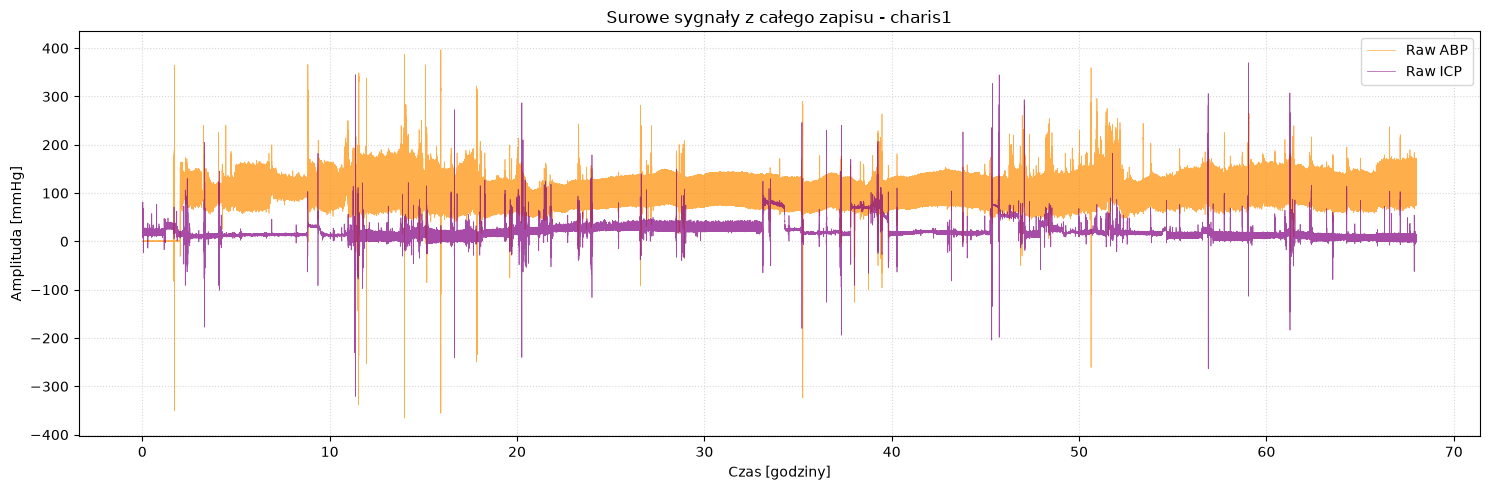

In [13]:

# =========================================================================
# 2. WCZYTYWANIE REKORDU I DIAGNOZA NA PODSTAWIE DETEKCJI
# =========================================================================
data_dir = 'charis-database-1.0.0'  
record_name = 'charis1'              

os.makedirs(data_dir, exist_ok=True)
local_path = os.path.join(data_dir, record_name)

record = wfdb.rdrecord(local_path)
signals = record.p_signal  
fs = record.fs  

channel_ABP = signals[:, 0]
channel_ICP = signals[:, 2]

# Uruchomienie obliczeń
processor = local_ICP_ABP_Processor(channel_ICP, channel_ABP, sampling_freq=fs, record_name=record_name)
processor.channel_icp.remove_noise(min_val=-1, max_val=100)
processor.process_all(event_detection_level = 25)


# Precyzyjny print diagnostyczny OPARTY WŁĄCZNIE NA WYNIKU ALGORYTMU
print("="*50)
print(f" DANE REKORDU: {record_name.upper()}")
if len(processor.final_segments) > 0:
    print(f" DIAGNOZA (z algorytmu): WYKRYTO TBI")
    print(f" Uzasadnienie: Znaleziono co najmniej jedno kwalifikowane zdarzenie.")
else:
    print(f" DIAGNOZA (z algorytmu): NIE STWIERDZONO TBI")
    print(f" Uzasadnienie: Brak zdarzeń spełniających pełne kryteria z artykułu.")
print("="*50 + "\n")


# =========================================================================
# 3. WYKRES NR 1: SUROWE SYGNAŁY PRZED ANALIZĄ
# =========================================================================
# Przeliczamy próbki na godziny
time_hours_raw = np.arange(len(channel_ICP)) / (fs * 3600)

fig_raw = plt.figure(figsize=(15, 5))
plt.plot(time_hours_raw, channel_ABP, color='darkorange', linewidth=0.5, alpha=0.7, label='Raw ABP')
plt.plot(time_hours_raw, channel_ICP, color='purple', linewidth=0.5, alpha=0.7, label='Raw ICP')
plt.title(f'Surowe sygnały z całego zapisu - {record_name}')
plt.xlabel('Czas [godziny]')
plt.ylabel('Amplituda [mmHg]')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()



In [14]:
# 4. WYKRES NR 2: "FIG. 7 EVENT DETECTION" (wersja Plotly)
# =========================================================================

# TWORZENIE SKORYGOWANEJ ŚREDNIEJ DO WYKRESU
processor.df['Adjusted_MICP'] = processor.df['MICP'].where(processor.df['is_valid'], other=np.nan).interpolate()

# Przeliczamy indeksy minutowe na godziny dla osi X
time_hours = processor.df.index / 60

# Tworzenie układu dwóch wykresów
fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.15,
    subplot_titles=(
        f'<b>Fig. 7 Event detection - {record_name}</b>', 
        '<i>Expanded view of the event</i>' if len(processor.final_segments) > 0 else '<i>Expanded view - Brak zdarzeń</i>'
    )
)

# --- WYKRES GŁÓWNY: CAŁOŚĆ (GÓRA, row=1) ---
fig.add_trace(
    go.Scatter(
        x=time_hours, 
        y=processor.df['Adjusted_MICP'], 
        mode='lines', 
        name='adjusted mean',
        line=dict(color='limegreen', width=1.5),
        legendgroup='top'
    ),
    row=1, col=1
)

max_y = max(60, processor.df['Adjusted_MICP'].max() + 5)

for i, seg in enumerate(processor.final_segments):
    start_h = seg['event_start_min'] / 60
    pre_start_h = seg['pre_event_start_min'] / 60
    
    threshold_val = 25.0 
    y_val = processor.df.loc[seg['event_start_min'], 'Adjusted_MICP']
    
    # Linia progu (threshold) przed zdarzeniem
    fig.add_trace(
        go.Scatter(
            x=[pre_start_h, start_h], 
            y=[threshold_val, threshold_val], 
            mode='lines',
            line=dict(color='crimson', width=2),
            showlegend=False,
            hoverinfo='skip'
        ),
        row=1, col=1
    )
    
    # Pusty czarny okrąg oznaczający początek zdarzenia
    fig.add_trace(
        go.Scatter(
            x=[start_h], 
            y=[y_val], 
            mode='markers',
            name='identified event start times' if i == 0 else '',
            showlegend=(i == 0), # Pokazujemy w legendzie tylko dla pierwszego obrotu pętli
            marker=dict(
                color='white', 
                line=dict(color='black', width=2), 
                size=10
            ),
            legendgroup='top'
        ),
        row=1, col=1
    )

# --- WYKRES ZBLIŻENIA: EXPANDED VIEW (DÓŁ, row=2) ---
if len(processor.final_segments) > 0:
    seg_zoom = processor.final_segments[0]
    pad_mins = 40
    zoom_start_min = max(0, seg_zoom['pre_event_start_min'] - pad_mins)
    zoom_end_min = min(len(processor.df) - 1, seg_zoom['event_end_min'] + pad_mins)
    
    df_zoom = processor.df.loc[zoom_start_min:zoom_end_min]
    time_hours_zoom = df_zoom.index / 60
    
    # Sygnał w zbliżeniu
    fig.add_trace(
        go.Scatter(
            x=time_hours_zoom, 
            y=df_zoom['Adjusted_MICP'], 
            mode='lines', 
            name='adjusted mean (zoom)',
            line=dict(color='limegreen', width=2),
            legendgroup='bottom'
        ),
        row=2, col=1
    )
    
    h_pre_start = seg_zoom['pre_event_start_min'] / 60
    h_event_start = seg_zoom['event_start_min'] / 60
    h_event_end = seg_zoom['event_end_min'] / 60
    
    # Niskie ICP przed eventem
    fig.add_trace(
        go.Scatter(
            x=[h_pre_start, h_event_start], 
            y=[25, 25], 
            mode='lines',
            name='low ICP before event (<25)',
            line=dict(color='crimson', width=3),
            legendgroup='bottom'
        ),
        row=2, col=1
    )
    
    # Wysokie ICP w trakcie eventu
    fig.add_trace(
        go.Scatter(
            x=[h_event_start, h_event_end], 
            y=[25, 25], 
            mode='lines',
            name='high ICP after event (>25)',
            line=dict(color='dodgerblue', width=3.5),
            legendgroup='bottom'
        ),
        row=2, col=1
    )
    
    y_zoom_start = processor.df.loc[seg_zoom['event_start_min'], 'Adjusted_MICP']
    
    # Marker w zoomie
    fig.add_trace(
        go.Scatter(
            x=[h_event_start], 
            y=[y_zoom_start], 
            mode='markers',
            showlegend=False,
            marker=dict(
                color='white', 
                line=dict(color='black', width=2), 
                size=12
            ),
            legendgroup='bottom'
        ),
        row=2, col=1
    )
else:
    # Wyświetlanie komunikatu o braku zdarzeń za pomocą adnotacji na środku drugiego okna
    fig.add_annotation(
        x=0.5, y=0.5,
        text="Brak zdarzeń spełniających<br>kryterium 1h czystego sygnału przed eventem.",
        xref="x2 domain", yref="y2 domain", # Odnosimy się do relatywnych współrzędnych osi 2
        showarrow=False,
        font=dict(size=14, color="gray"),
        align="center"
    )

# --- KONFIGURACJA OLAUTU I OSI ---
fig.update_yaxes(title_text="mmHg", range=[0, max_y], gridcolor='rgba(200, 200, 200, 0.3)', row=1, col=1)
fig.update_xaxes(title_text="Time in hours", gridcolor='rgba(200, 200, 200, 0.3)', row=1, col=1)

fig.update_yaxes(title_text="mmHg", gridcolor='rgba(200, 200, 200, 0.3)', row=2, col=1)
fig.update_xaxes(title_text="Time in hours", gridcolor='rgba(200, 200, 200, 0.3)', row=2, col=1)

fig.update_layout(
    template='plotly_white',
    height=800,  # Symuluje figsize z matplotlib
    width=1400,
    hovermode='x unified', # Łączy hover dane dla obu wykresów po najechaniu na oś X
    title_font=dict(size=16)
)

fig.show()

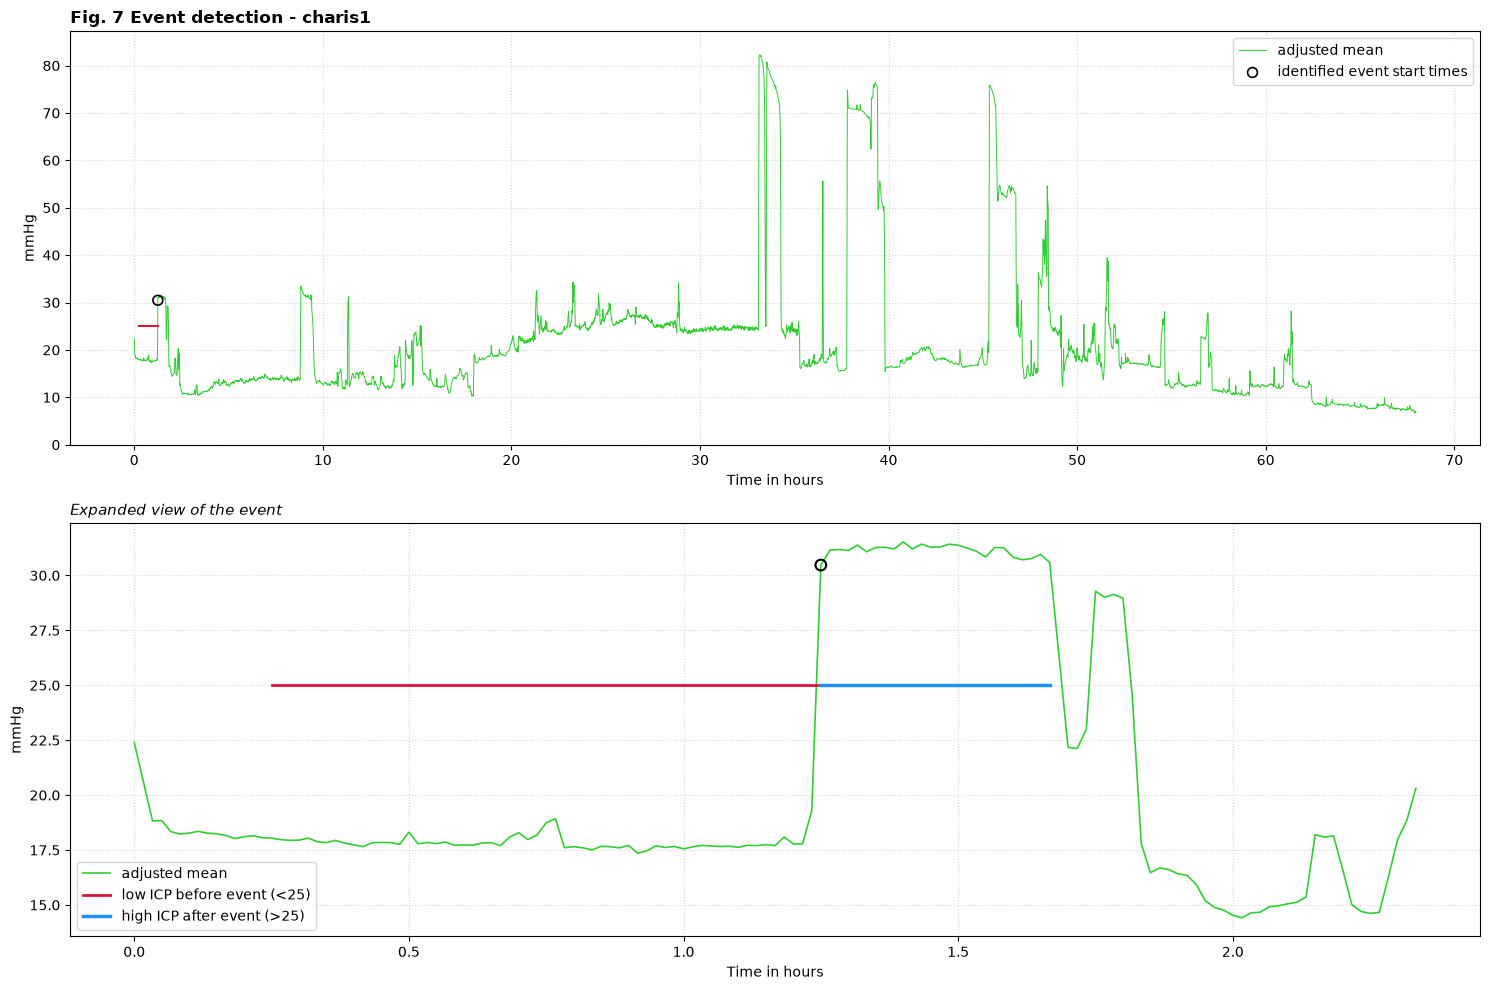

In [11]:
# 4. WYKRES NR 2: "FIG. 7 EVENT DETECTION"
# =========================================================================
# TWORZENIE SKORYGOWANEJ ŚREDNIEJ DO WYKRESU
processor.df['Adjusted_MICP'] = processor.df['MICP'].where(processor.df['is_valid'], other=np.nan).interpolate()

# Tworzymy dwa wykresy jeden pod drugim
fig_event, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Przeliczamy indeksy minutowe z ramki DataFrame na godziny dla osi X
time_hours = processor.df.index / 60

# --- WYKRES GŁÓWNY: CAŁOŚĆ (GÓRA) ---
ax1.plot(time_hours, processor.df['Adjusted_MICP'], color='limegreen', linewidth=0.7, label='adjusted mean')

for i, seg in enumerate(processor.final_segments):
    start_h = seg['event_start_min'] / 60
    pre_start_h = seg['pre_event_start_min'] / 60
    
    threshold_val = 25.0 
    y_val = processor.df.loc[seg['event_start_min'], 'Adjusted_MICP']
    
    ax1.plot([pre_start_h, start_h], [threshold_val, threshold_val], color='crimson', linewidth=1.5, zorder=3)
    
    lbl = 'identified event start times' if i == 0 else ""
    ax1.scatter(start_h, y_val, facecolors='none', edgecolors='black', s=50, linewidth=1.2, zorder=4, label=lbl)

ax1.set_title(f'Fig. 7 Event detection - {record_name}', fontsize=12, fontweight='bold', loc='left')
ax1.set_xlabel('Time in hours')
ax1.set_ylabel('mmHg')

max_y = max(60, processor.df['Adjusted_MICP'].max() + 5)
ax1.set_ylim(0, max_y)

ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend(loc='upper right')

# --- WYKRES ZBLIŻENIA: EXPANDED VIEW (DÓŁ) ---
if len(processor.final_segments) > 0:
    seg_zoom = processor.final_segments[0]
    pad_mins = 40
    zoom_start_min = max(0, seg_zoom['pre_event_start_min'] - pad_mins)
    zoom_end_min = min(len(processor.df) - 1, seg_zoom['event_end_min'] + pad_mins)
    
    df_zoom = processor.df.loc[zoom_start_min:zoom_end_min]
    time_hours_zoom = df_zoom.index / 60
    
    ax2.plot(time_hours_zoom, df_zoom['Adjusted_MICP'], color='limegreen', linewidth=1.2, label='adjusted mean')
    
    h_pre_start = seg_zoom['pre_event_start_min'] / 60
    h_event_start = seg_zoom['event_start_min'] / 60
    h_event_end = seg_zoom['event_end_min'] / 60
    
    ax2.plot([h_pre_start, h_event_start], [25, 25], color='crimson', linewidth=2, label='low ICP before event (<25)')
    ax2.plot([h_event_start, h_event_end], [25, 25], color='dodgerblue', linewidth=2.5, label='high ICP after event (>25)')
    
    y_zoom_start = processor.df.loc[seg_zoom['event_start_min'], 'Adjusted_MICP']
    ax2.scatter(h_event_start, y_zoom_start, facecolors='none', edgecolors='black', s=60, linewidth=1.5, zorder=4)
    
    ax2.set_title(f'Expanded view of the event', fontsize=11, style='italic', loc='left')
    ax2.set_xlabel('Time in hours')
    ax2.set_ylabel('mmHg')
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.legend(loc='lower left')
else:
    ax2.text(0.5, 0.5, "Brak zdarzeń spełniających\nkryterium 1h czystego sygnału przed eventem.", 
             ha='center', va='center', fontsize=12, color='gray')

fig_event.tight_layout()

# Wyświetlamy oba okna z wykresami jednocześnie
plt.show()